# Umbrales: la línea de corte

**Material desarrollado para el IFTS 24 - 2026**

**Espacio:** Laboratorio de Tecnologías de la Imagen Digital

---

## Objetivo

En el cuaderno anterior aprendimos a leer el histograma de una imagen. En este cuaderno vamos a usar esa distribución para trazar una línea de corte que separe automáticamente los objetos del fondo: eso se llama umbralización o thresholding.

## Al terminar este material van a poder:

1. Aplicar un umbral manual a una imagen en escala de grises y obtener su versión binaria.
2. Invertir el criterio de binarización.
3. Calcular el umbral óptimo de forma automática con el método de Otsu.
4. Diferenciar la umbralización global de la local, y reconocer cuál corresponde según el tipo de fondo.
5. Aplicar umbralización local sobre una imagen con iluminación despareja.
6. Producir una comparación visual de los distintos métodos sobre una imagen propia.

## Microglosario

| Término | Significado en lenguaje llano |
|---|---|
| Umbral (threshold) | Un valor de intensidad que usamos como línea de corte entre píxeles oscuros y claros. |
| Umbralización (thresholding) | El proceso de convertir una imagen en blanco y negro puro a partir de un umbral. |
| Binarización | Sinónimo de umbralización: el resultado tiene solo dos valores posibles. |
| Segmentación | Separar una imagen en regiones, por ejemplo objeto y fondo. |
| Umbral global | Un único umbral que se aplica a toda la imagen por igual. |
| Umbral local (adaptativo) | Un umbral que cambia según la zona de la imagen, útil cuando la iluminación no es pareja. |
| Método de Otsu | Un algoritmo que calcula automáticamente el mejor umbral global a partir del histograma. |

## Trazar una línea sobre el histograma

Volvamos al histograma del cuaderno anterior: un gráfico de barras que cuenta cuántos píxeles hay en cada nivel de intensidad.

Umbralizar es, ni más ni menos, trazar una línea vertical sobre ese gráfico: todo lo que queda a la derecha de la línea se convierte en blanco, todo lo que queda a la izquierda se convierte en negro. Es como usar un colador: lo que pasa por los agujeros va para un lado, lo que no pasa va para el otro.

La pregunta clave es dónde trazar esa línea. Vamos a probar primero eligiéndola nosotros a mano, y después vamos a dejar que un algoritmo la calcule por nosotros.

## 1. Recuperamos el punto de partida

Cargamos de nuevo las librerías y una imagen clásica para trabajar con umbrales: una foto de monedas sobre un fondo parejo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.filters import try_all_threshold
from skimage.filters import threshold_otsu
from skimage.filters import threshold_local

print("✓ Librerías cargadas correctamente.")

✓ Librerías cargadas correctamente.


In [2]:
def mostrar_imagen(imagen, titulo="Imagen", mapa_color="gray"):
    plt.figure(figsize=(7, 5))
    plt.imshow(imagen, cmap=mapa_color)
    plt.title(titulo)
    plt.axis("off")
    plt.show()

print("✓ Función mostrar_imagen creada correctamente.")

✓ Función mostrar_imagen creada correctamente.


In [3]:
imagen_monedas = data.coins()

print("✓ Imagen de monedas cargada.")
print("Forma:", imagen_monedas.shape)

✓ Imagen de monedas cargada.
Forma: (303, 384)


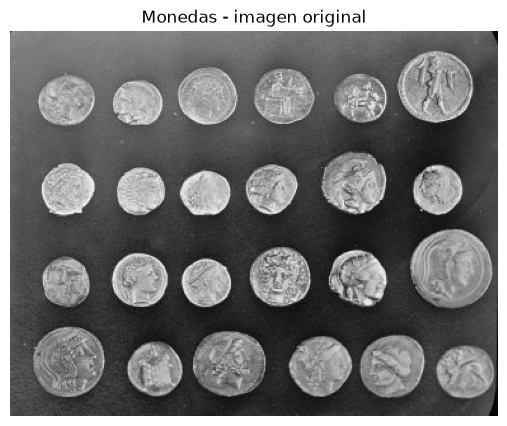

In [4]:
mostrar_imagen(imagen_monedas, "Monedas - imagen original")

### Para pensar

- Mirando la imagen, ¿el fondo les parece parejo (misma iluminación en toda la imagen) o desparejo?
- Si tuvieran que separar las monedas del fondo a simple vista, ¿qué regla usarían?

## 2. El histograma de las monedas

Antes de elegir dónde cortar, volvamos a mirar el histograma, como hicimos en el cuaderno anterior. Umbralizar es, justamente, trazar una línea vertical sobre este gráfico.

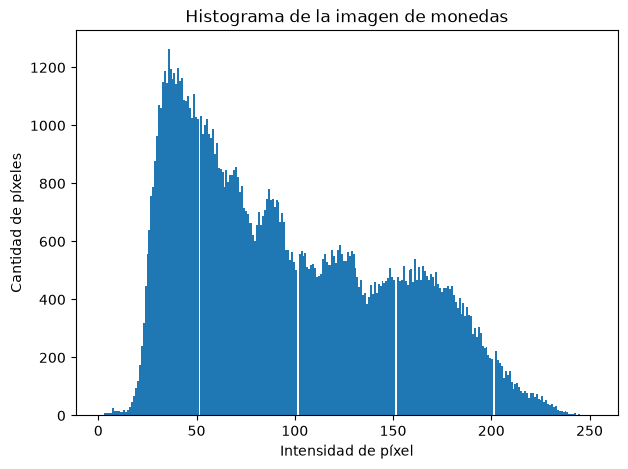

✓ Histograma generado.


In [5]:
plt.figure(figsize=(7, 5))
plt.hist(imagen_monedas.ravel(), bins=256)
plt.title("Histograma de la imagen de monedas")
plt.xlabel("Intensidad de píxel")
plt.ylabel("Cantidad de píxeles")
plt.show()

print("✓ Histograma generado.")

### Para pensar

- Mirando este histograma, ¿en qué zona del eje horizontal trazarían ustedes la línea de corte entre fondo y monedas?
- ¿El histograma tiene dos grupos bien diferenciados (dos "jorobas") o los valores están mezclados?

## 3. Umbral manual

Elegimos un valor de corte a mano y lo aplicamos a toda la imagen. `imagen > umbral` compara cada píxel contra ese valor y devuelve `True` (blanco) o `False` (negro).

In [6]:
umbral_manual = 100

imagen_binaria = imagen_monedas > umbral_manual

print("✓ Umbral aplicado.")
print("Umbral usado:", umbral_manual)

✓ Umbral aplicado.
Umbral usado: 100


Grafiquemos otra vez el histograma, ahora marcando dónde cae nuestra línea de corte.

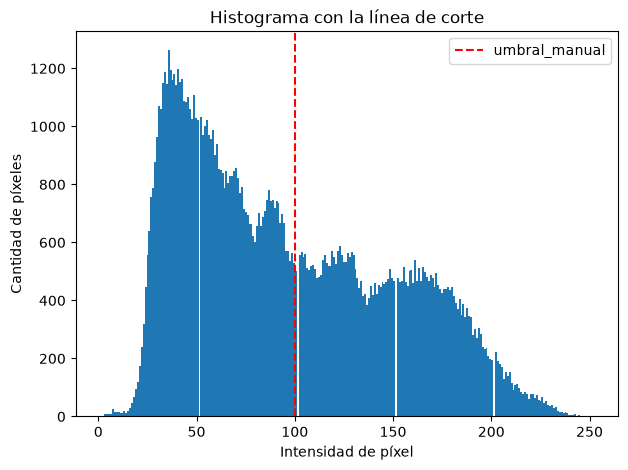

✓ Línea de corte visualizada.


In [7]:
plt.figure(figsize=(7, 5))
plt.hist(imagen_monedas.ravel(), bins=256)
plt.axvline(umbral_manual, color="red", linestyle="--", label="umbral_manual")
plt.title("Histograma con la línea de corte")
plt.xlabel("Intensidad de píxel")
plt.ylabel("Cantidad de píxeles")
plt.legend()
plt.show()

print("✓ Línea de corte visualizada.")

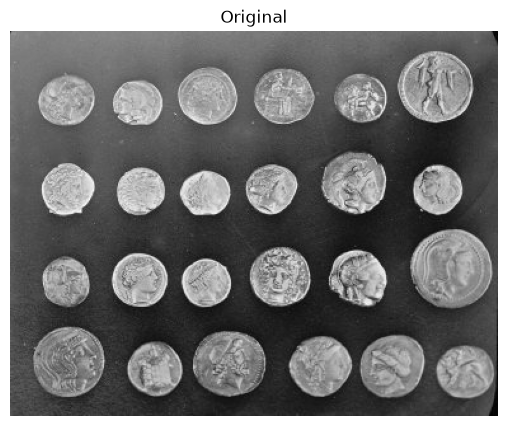

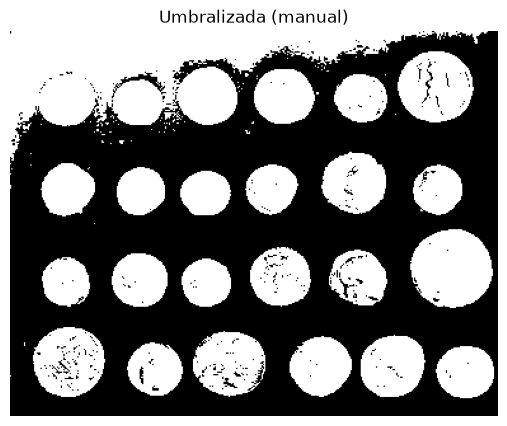

In [8]:
mostrar_imagen(imagen_monedas, "Original")
mostrar_imagen(imagen_binaria, "Umbralizada (manual)")

### Para pensar

- ¿Las monedas quedaron en blanco o en negro con este umbral?
- Prueben cambiar `umbral_manual` por otro valor (por ejemplo 80 o 150) y vuelvan a correr las celdas anteriores. ¿Qué cambia?

## 4. Umbral invertido

A veces nos interesa el criterio contrario: que lo oscuro quede en blanco y lo claro en negro. Alcanza con invertir la comparación.

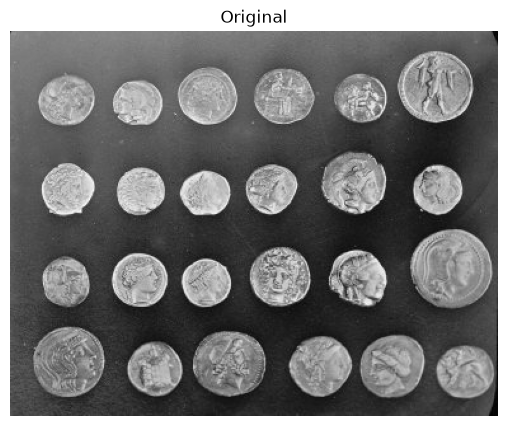

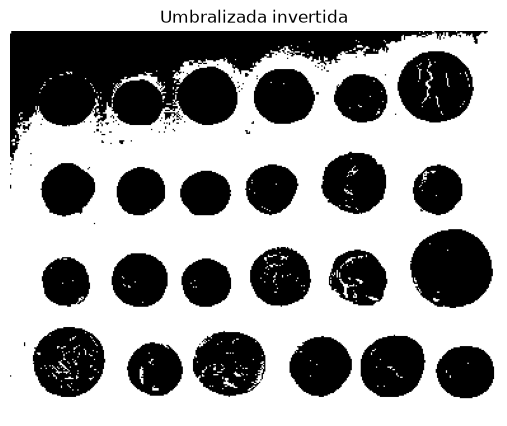

✓ Umbral invertido aplicado.


In [9]:
imagen_binaria_invertida = imagen_monedas <= umbral_manual

mostrar_imagen(imagen_monedas, "Original")
mostrar_imagen(imagen_binaria_invertida, "Umbralizada invertida")

print("✓ Umbral invertido aplicado.")

### Para pensar

- ¿En qué situación real les parece más útil que el objeto quede en blanco? ¿Y en cuál que quede en negro?

## 5. El problema de elegir el umbral a mano

Elegir el umbral a mano tiene un problema: depende de mirar la imagen y probar valores por prueba y error. Con miles de imágenes distintas, eso no escala.

`scikit-image` incluye una función que prueba varios algoritmos de umbralización automática a la vez, para comparar resultados de un vistazo.

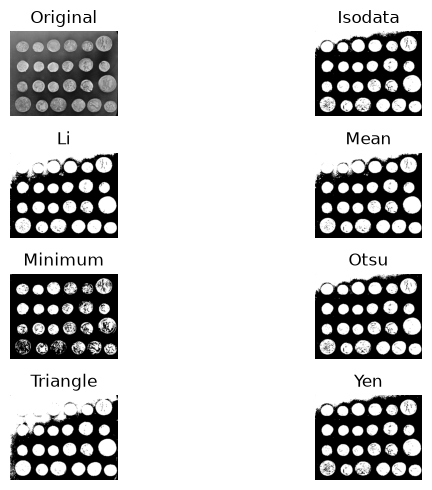

✓ Comparación de algoritmos generada.


In [10]:
figura, ejes = try_all_threshold(imagen_monedas, verbose=False)
plt.show()

print("✓ Comparación de algoritmos generada.")

### Para pensar

- ¿Todos los métodos producen el mismo resultado?
- ¿Cuál de ellos les parece que separa mejor las monedas del fondo?

## 6. Umbral óptimo global: método de Otsu

El método de Otsu calcula automáticamente el umbral que mejor separa el histograma en dos grupos: fondo y objeto. Es un método global: usa un único valor para toda la imagen, por eso funciona bien cuando el fondo es parejo, como en esta imagen de monedas.

In [11]:
umbral_otsu = threshold_otsu(imagen_monedas)

print("✓ Umbral óptimo calculado con Otsu.")
print("Umbral de Otsu:", umbral_otsu)
print("Umbral que habíamos elegido a mano:", umbral_manual)

✓ Umbral óptimo calculado con Otsu.
Umbral de Otsu: 107
Umbral que habíamos elegido a mano: 100


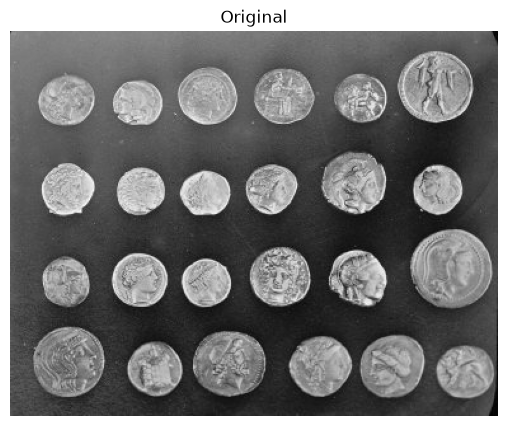

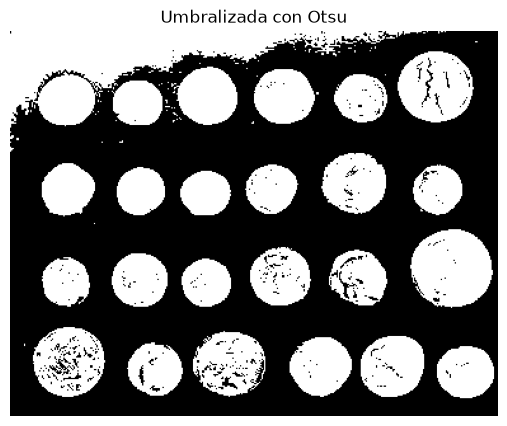

In [12]:
imagen_binaria_otsu = imagen_monedas > umbral_otsu

mostrar_imagen(imagen_monedas, "Original")
mostrar_imagen(imagen_binaria_otsu, "Umbralizada con Otsu")

### Para pensar

- ¿El umbral de Otsu quedó cerca o lejos del valor que habían probado a mano?
- ¿El resultado visual les parece mejor, peor o igual que el umbral manual?

## 7. Cuando el fondo no es parejo: umbral local

Otsu funciona bien con fondo uniforme, pero falla cuando la iluminación cambia dentro de la misma imagen (por ejemplo, una hoja escaneada con más luz de un lado que del otro). Ahí conviene un umbral local: en vez de un único valor para toda la imagen, se calcula un valor distinto para cada zona.

Es como iluminar una habitación con varias lámparas en vez de una sola: cada rincón necesita su propio ajuste.

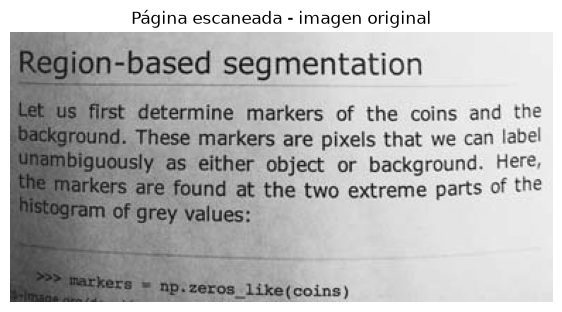

✓ Imagen de texto cargada.


In [13]:
imagen_texto = data.page()

mostrar_imagen(imagen_texto, "Página escaneada - imagen original")

print("✓ Imagen de texto cargada.")

### Para pensar

- ¿Se nota a simple vista alguna zona más iluminada que otra en esta imagen?
- Si aplicáramos Otsu directamente sobre esta imagen, ¿qué problema esperarían encontrar?

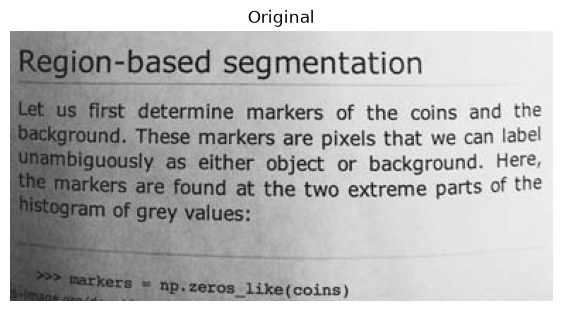

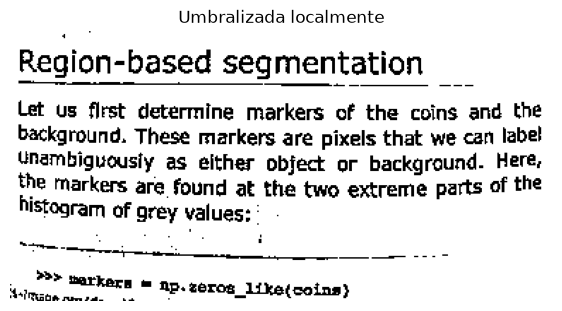

✓ Umbral local aplicado.
Tamaño de bloque usado: 35


In [14]:
tamano_bloque = 35

umbral_local = threshold_local(imagen_texto, tamano_bloque, offset=10)

imagen_binaria_local = imagen_texto > umbral_local

mostrar_imagen(imagen_texto, "Original")
mostrar_imagen(imagen_binaria_local, "Umbralizada localmente")

print("✓ Umbral local aplicado.")
print("Tamaño de bloque usado:", tamano_bloque)

### Para pensar

- Prueben cambiar `tamano_bloque` por un número más chico (por ejemplo 15) y por uno más grande (por ejemplo 61). ¿Cómo cambia el resultado?
- ¿Qué representa, en términos prácticos, el parámetro `tamano_bloque`?

## 8. Global vs. local: cuándo usar cada uno

| Tipo de umbral | Cuándo usarlo | Ejemplo en este cuaderno |
|---|---|---|
| Global (Otsu) | Fondo con iluminación pareja en toda la imagen | Imagen de monedas |
| Local (adaptativo) | Fondo con iluminación despareja entre zonas | Página escaneada |

## Actividad de producción

Elijan una imagen propia de `scikit-image` (por ejemplo `data.camera()` o `data.astronaut()`, convertida a escala de grises) y armen una figura de cuatro paneles:

1. Imagen original
2. Umbralizada con un valor manual a elección
3. Umbralizada con Otsu
4. Umbralizada localmente

In [15]:
# ─── Espacio de práctica: producción final ────────────────────────────────
#
# 1. Elijan una imagen de ejemplo y conviértanla a escala de grises si hace falta
# 2. Apliquen umbral manual, Otsu y umbral local
# 3. Armen una figura de 4 paneles (pueden usar plt.subplots(2, 2, ...) como en el cuaderno 1)
# 4. Muestren la figura con plt.show()
#
# Bonus: agreguen un quinto panel con el histograma de la imagen original
#
# ─────────────────────────────────────────────────────────────────────────


## Cierre

En este cuaderno aprendimos a separar objetos del fondo mediante umbralización: primero a mano, después con el método automático de Otsu, y finalmente con umbral local para fondos con iluminación despareja.

Con esto cerramos el bloque de fundamentos: ya sabemos representar una imagen como array, leer su histograma y segmentarla con umbrales. En el próximo encuentro vamos a dar un paso más y trabajar con filtros: suavizado, nitidez y detección de bordes.